/tmp/ipykernel_2188/3646787323.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(he_img.ravel(), 256, [0, 256])


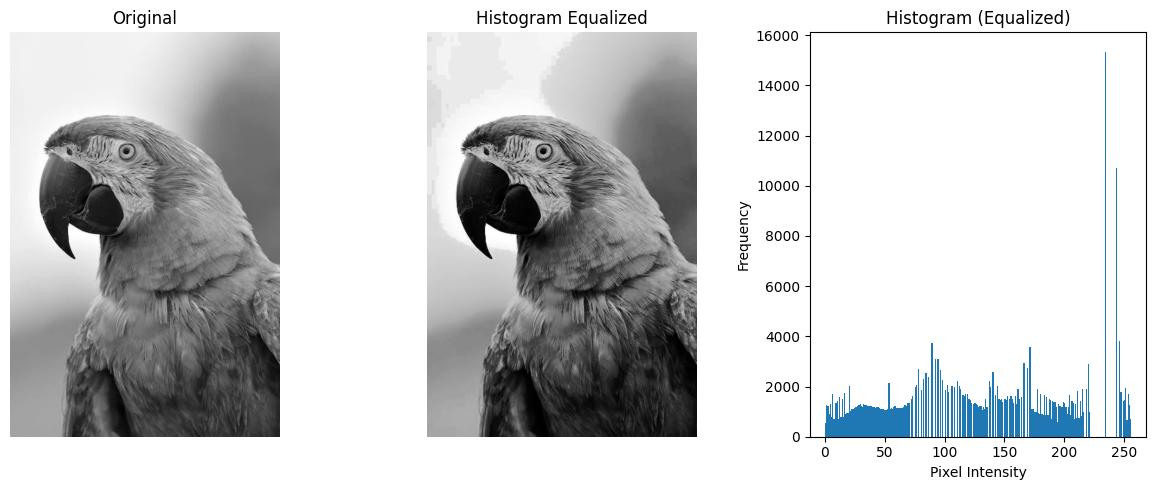

In [20]:
import cv2
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread("/content/sample_data/lq.jpg.jpg", 0)

# Apply Histogram Equalization
he_img = cv2.equalizeHist(img)

# Display results
plt.figure(figsize=(12, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.axis("off")

# Histogram Equalized Image
plt.subplot(1, 3, 2)
plt.title("Histogram Equalized")
plt.imshow(he_img, cmap="gray")
plt.axis("off")

# Histogram of Equalized Image
plt.subplot(1, 3, 3)
plt.title("Histogram (Equalized)")
plt.hist(he_img.ravel(), 256, [0, 256])
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

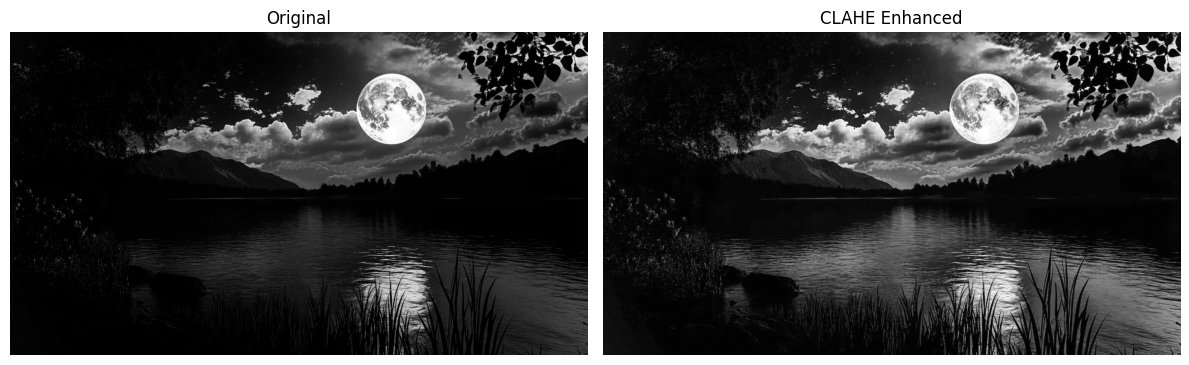

In [22]:
# Point Processing
# CLAHE

import cv2
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread("/content/sample_data/WhatsApp Image 2025-12-02 at 22.18.50_63b160f1.jpg", 0)

# Check if image is loaded
if img is None:
    print("Image not found. Check the file name.")
else:
    # Create CLAHE object
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # Apply enhancement
    clahe_img = clahe.apply(img)

    # Plot
    plt.figure(figsize=(12, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    # CLAHE Enhanced Image
    plt.subplot(1, 2, 2)
    plt.title("CLAHE Enhanced")
    plt.imshow(clahe_img, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

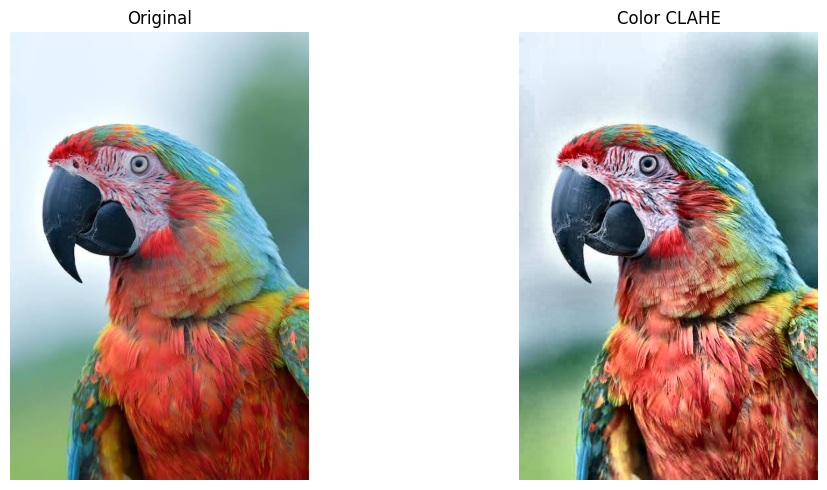

In [23]:
# Point Processing
# Color Enhancement using CLAHE

import cv2
import matplotlib.pyplot as plt

# Load color image
img = cv2.imread("/content/sample_data/lq.jpg.jpg")

# Check if image is loaded
if img is None:
    print("Image not found. Check the file name and path.")
else:
    # Convert BGR to YCrCb
    img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

    # Split Y, Cr, Cb channels
    Y, Cr, Cb = cv2.split(img_ycrcb)

    # Apply CLAHE on Y channel
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    Y_clahe = clahe.apply(Y)

    # Merge channels
    img_clahe = cv2.merge((Y_clahe, Cr, Cb))

    # Convert YCrCb back to BGR
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_YCrCb2BGR)

    # Display results
    plt.figure(figsize=(12, 5))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    # Color CLAHE Image
    plt.subplot(1, 2, 2)
    plt.title("Color CLAHE")
    plt.imshow(cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

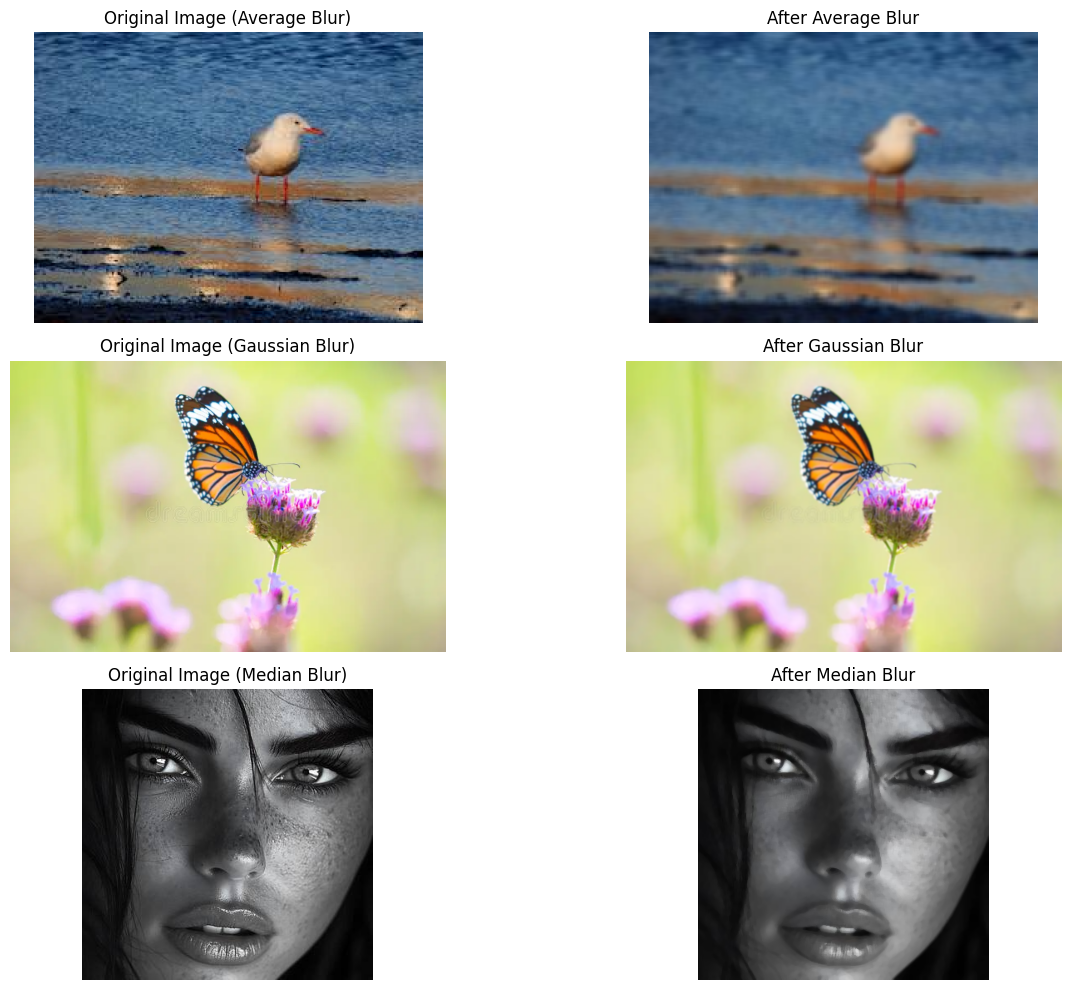

In [24]:
# Spatial Domain Filtering - Smoothing

import cv2
import matplotlib.pyplot as plt

# ------------------------------
# Load 3 different images
# ------------------------------
img_avg = cv2.imread("/content/sample_data/images (1).jpg")
img_gauss = cv2.imread("/content/sample_data/guindineau-sur-des-fleurs-109414654.webp")
img_median = cv2.imread("/content/sample_data/images.jpg")

# Check loading
if img_avg is None:
    print("Average blur image not found!")

if img_gauss is None:
    print("Gaussian blur image not found!")

if img_median is None:
    print("Median blur image not found!")

# Continue only if all images are loaded
if img_avg is not None and img_gauss is not None and img_median is not None:

    # Convert BGR → RGB for correct display
    img_avg_rgb = cv2.cvtColor(img_avg, cv2.COLOR_BGR2RGB)
    img_gauss_rgb = cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB)
    img_median_rgb = cv2.cvtColor(img_median, cv2.COLOR_BGR2RGB)

    # ------------------------------
    # Apply filters
    # ------------------------------

    # 1. Average Smoothing
    avg_blur = cv2.blur(img_avg, (5, 5))
    avg_blur_rgb = cv2.cvtColor(avg_blur, cv2.COLOR_BGR2RGB)

    # 2. Gaussian Smoothing
    gaussian_blur = cv2.GaussianBlur(img_gauss, (5, 5), 0)
    gaussian_blur_rgb = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)

    # 3. Median Smoothing
    median_blur = cv2.medianBlur(img_median, 5)
    median_blur_rgb = cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB)

    # ------------------------------
    # Display Before and After
    # ------------------------------
    plt.figure(figsize=(14, 10))

    # ----- Average Blur -----
    plt.subplot(3, 2, 1)
    plt.imshow(img_avg_rgb)
    plt.title("Original Image (Average Blur)")
    plt.axis("off")

    plt.subplot(3, 2, 2)
    plt.imshow(avg_blur_rgb)
    plt.title("After Average Blur")
    plt.axis("off")

    # ----- Gaussian Blur -----
    plt.subplot(3, 2, 3)
    plt.imshow(img_gauss_rgb)
    plt.title("Original Image (Gaussian Blur)")
    plt.axis("off")

    plt.subplot(3, 2, 4)
    plt.imshow(gaussian_blur_rgb)
    plt.title("After Gaussian Blur")
    plt.axis("off")

    # ----- Median Blur -----
    plt.subplot(3, 2, 5)
    plt.imshow(img_median_rgb)
    plt.title("Original Image (Median Blur)")
    plt.axis("off")

    plt.subplot(3, 2, 6)
    plt.imshow(median_blur_rgb)
    plt.title("After Median Blur")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Saving images.jpg to images (1).jpg


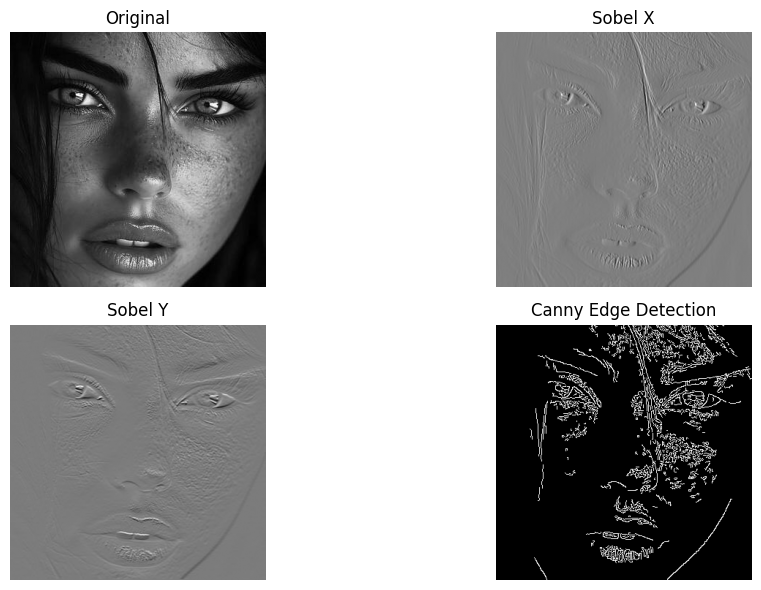

In [26]:
# Spatial Domain Filtering
# Edge Detection

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(image_path, 0)

# Check if image is loaded
if img is None:
    print("Error: Image could not be loaded.")
else:

    # 1. Sobel Edge Detection
    sobel_x = cv2.Sobel(
        img, cv2.CV_64F, 1, 0, ksize=3
    )  # Vertical edges

    sobel_y = cv2.Sobel(
        img, cv2.CV_64F, 0, 1, ksize=3
    )  # Horizontal edges

    # 2. Canny Edge Detection
    canny_edges = cv2.Canny(img, 100, 200)

    # Display results
    plt.figure(figsize=(12, 6))

    # Original
    plt.subplot(2, 2, 1)
    plt.title("Original")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    # Sobel X
    plt.subplot(2, 2, 2)
    plt.title("Sobel X")
    plt.imshow(sobel_x, cmap="gray")
    plt.axis("off")

    # Sobel Y
    plt.subplot(2, 2, 3)
    plt.title("Sobel Y")
    plt.imshow(sobel_y, cmap="gray")
    plt.axis("off")

    # Canny
    plt.subplot(2, 2, 4)
    plt.title("Canny Edge Detection")
    plt.imshow(canny_edges, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()